In [3]:
import exifread

def get_exif_exifread(image_path):
    with open(image_path, 'rb') as f:
        tags = exifread.process_file(f, details=False)
    return tags

# Example usage
metadata = get_exif_exifread("../data/camera_trap_dataset_filtered/animal_images/02020392.JPG")
for tag in metadata.keys():
    print(f"{tag}: {metadata[tag]}")

Image ImageDescription: M2E0A0L0-0.0-E0A0-0.0-E0A0------
Image Make: KEEPGUARD
Image Model: 
Image Orientation: Horizontal (normal)
Image XResolution: 72
Image YResolution: 72
Image ResolutionUnit: Pixels/Inch
Image Software: KG790C2Dx14218
Image DateTime: 2025:02:02 00:12:04
Image YCbCrPositioning: Co-sited
Image Tag 0x8292: [67, 111, 112, 121, 114, 105, 103, 104, 116, 32, 50, 48, 48, 56]
Image ExifOffset: 366
GPS GPSAltitude: 0
GPS GPSSpeed: 0
GPS GPSImgDirection: 2
Image GPSInfo: 42474
Thumbnail Compression: JPEG (old-style)
Thumbnail Orientation: Horizontal (normal)
Thumbnail XResolution: 96
Thumbnail YResolution: 96
Thumbnail ResolutionUnit: Pixels/Inch
Thumbnail JPEGInterchangeFormat: 42688
Thumbnail JPEGInterchangeFormatLength: 5405
Thumbnail YCbCrPositioning: Co-sited
EXIF ExposureTime: 1
EXIF FNumber: 14/5
EXIF ExposureProgram: Program Normal
EXIF ISOSpeedRatings: 50
EXIF ExifVersion: 0220
EXIF DateTimeOriginal: 2025:02:02 00:12:04
EXIF DateTimeDigitized: 2025:02:02 00:12:04
E

Found 1583 images, testing on 20 samples
Processing image 1/20: ../data/camera_trap_dataset_filtered/animal_images/02030541.JPG


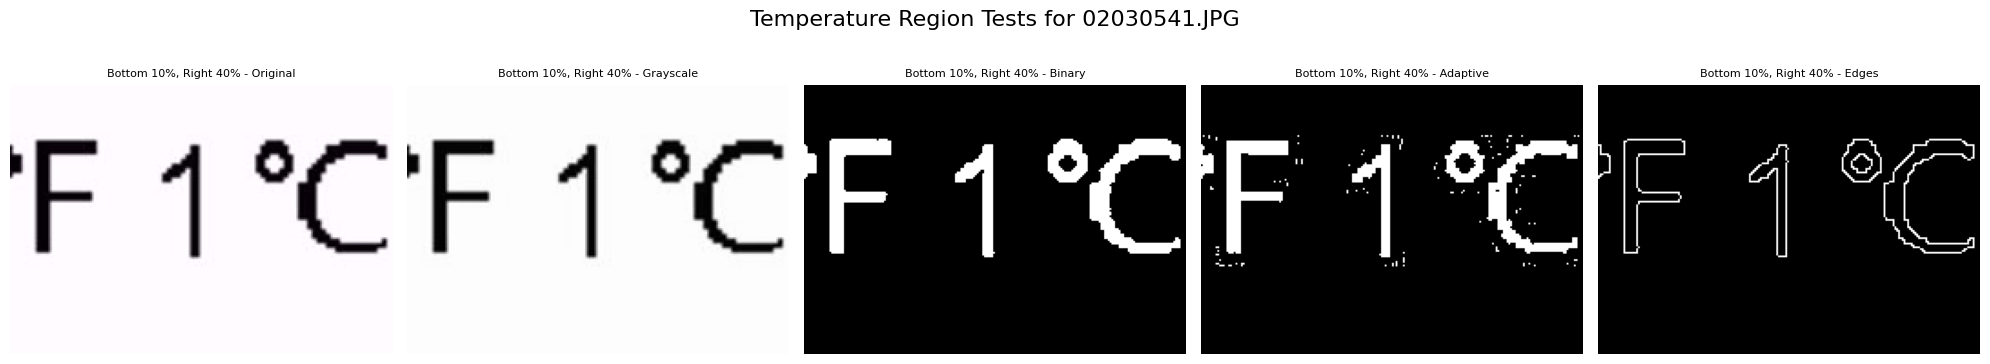

Processing image 2/20: ../data/camera_trap_dataset_filtered/animal_images/02100895.JPG


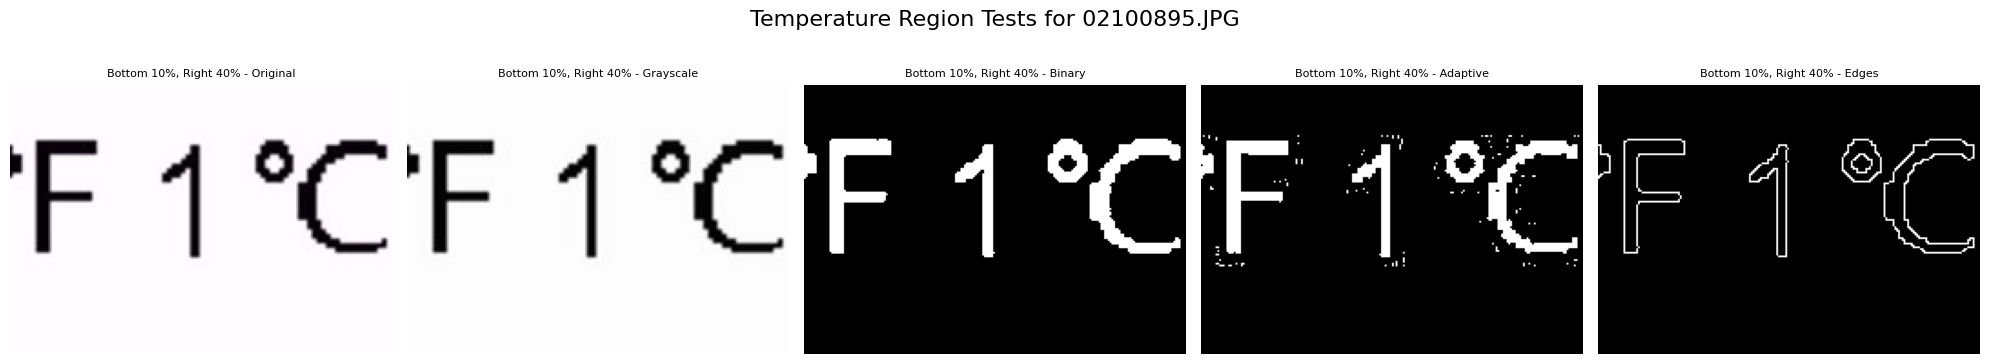

Processing image 3/20: ../data/camera_trap_dataset_filtered/animal_images/04200954.JPG


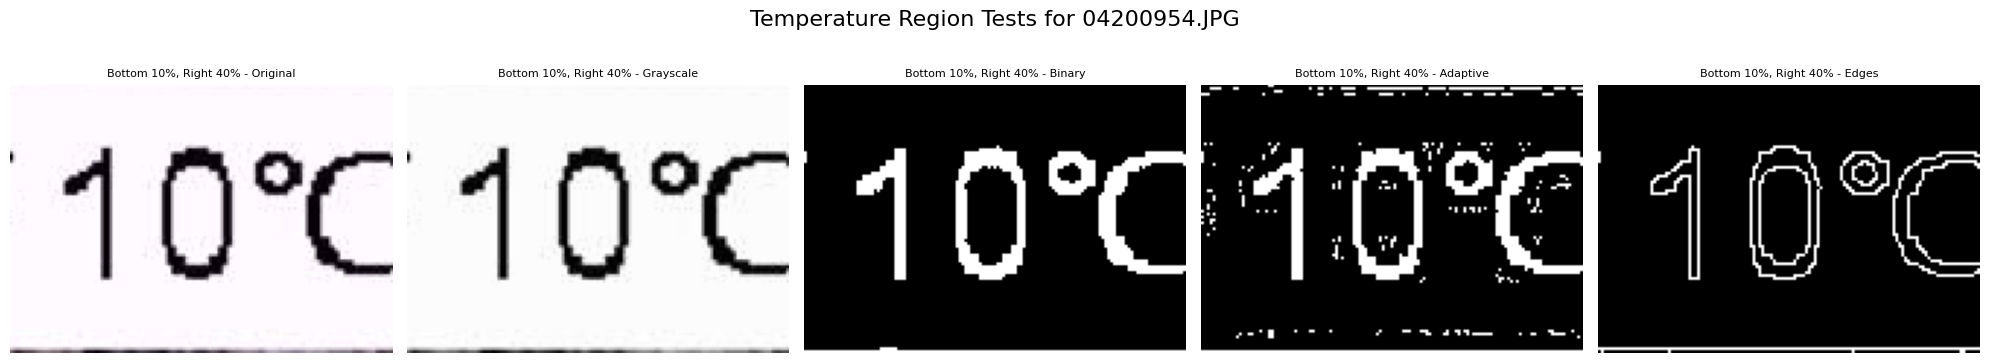

Processing image 4/20: ../data/camera_trap_dataset_filtered/animal_images/04200971.JPG


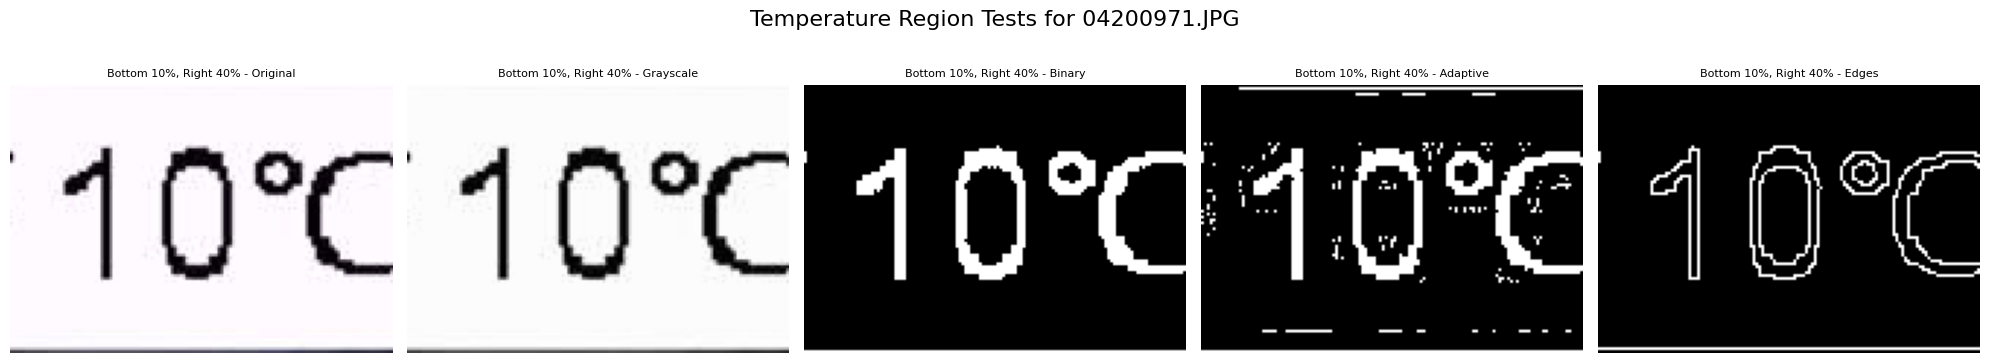

Processing image 5/20: ../data/camera_trap_dataset_filtered/animal_images/04240234.JPG


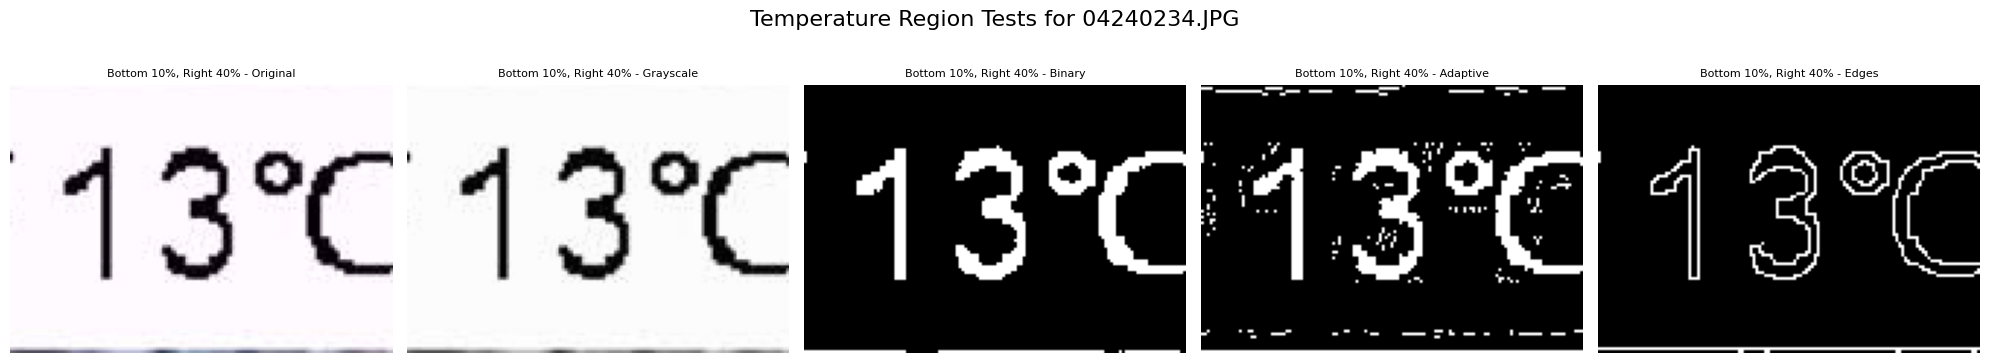

Processing image 6/20: ../data/camera_trap_dataset_filtered/animal_images/02270488.JPG


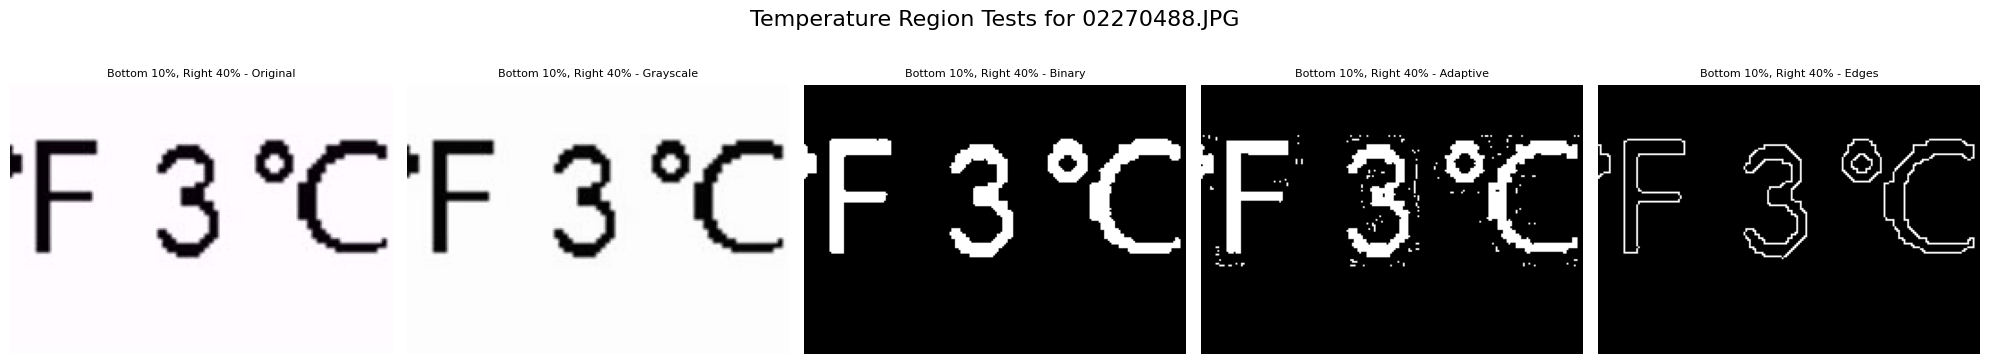

Processing image 7/20: ../data/camera_trap_dataset_filtered/animal_images/03090773.JPG


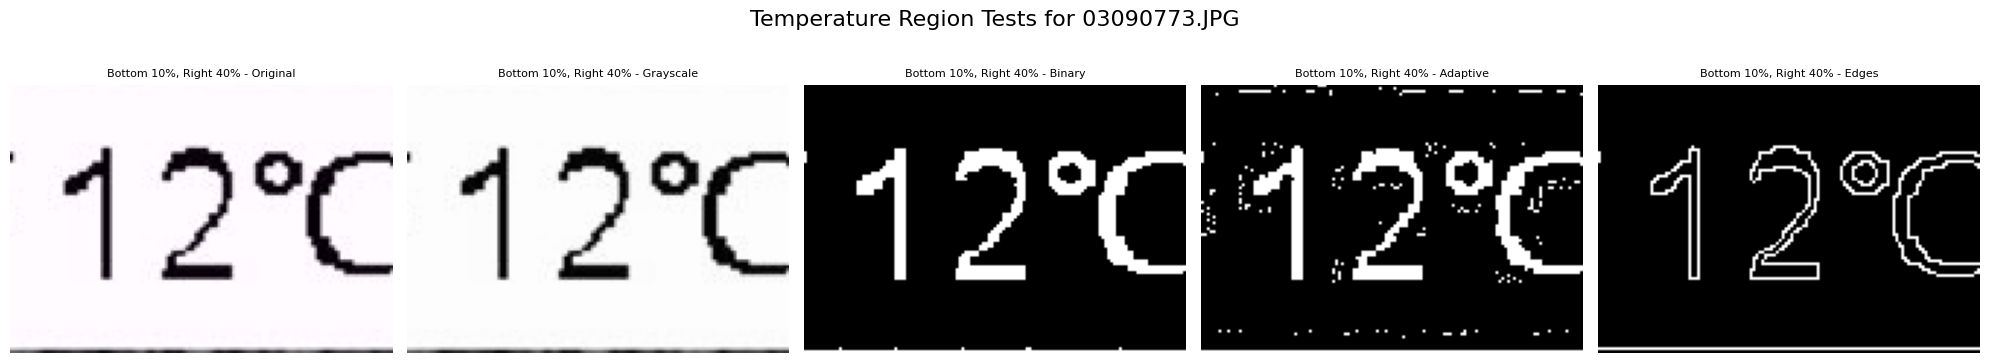

Processing image 8/20: ../data/camera_trap_dataset_filtered/animal_images/02120109.JPG


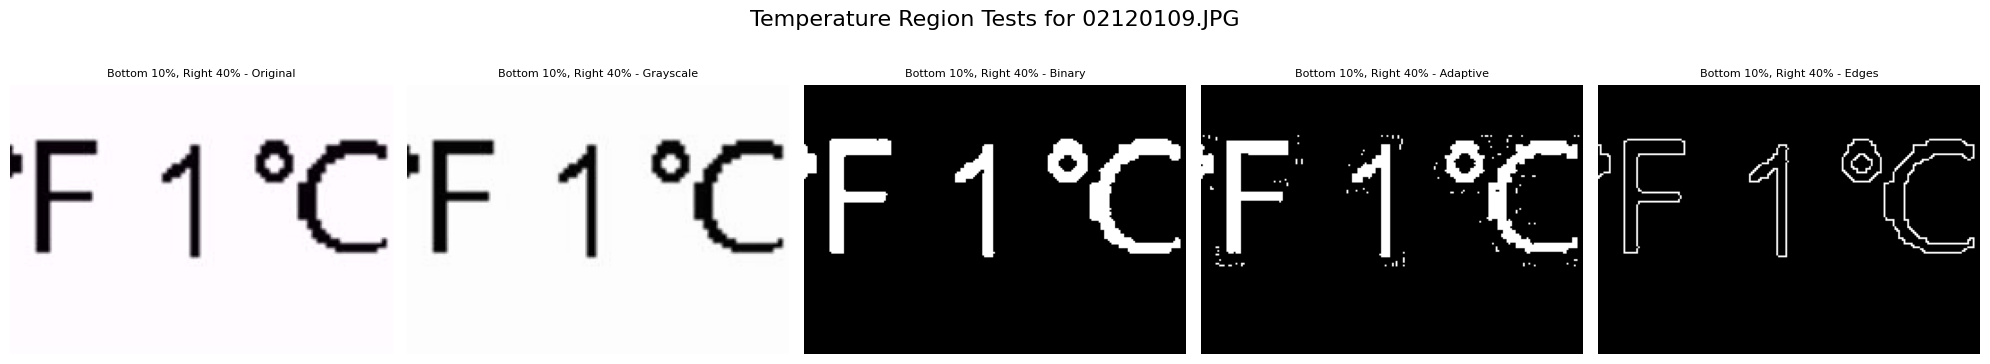

Processing image 9/20: ../data/camera_trap_dataset_filtered/animal_images/04140687.JPG


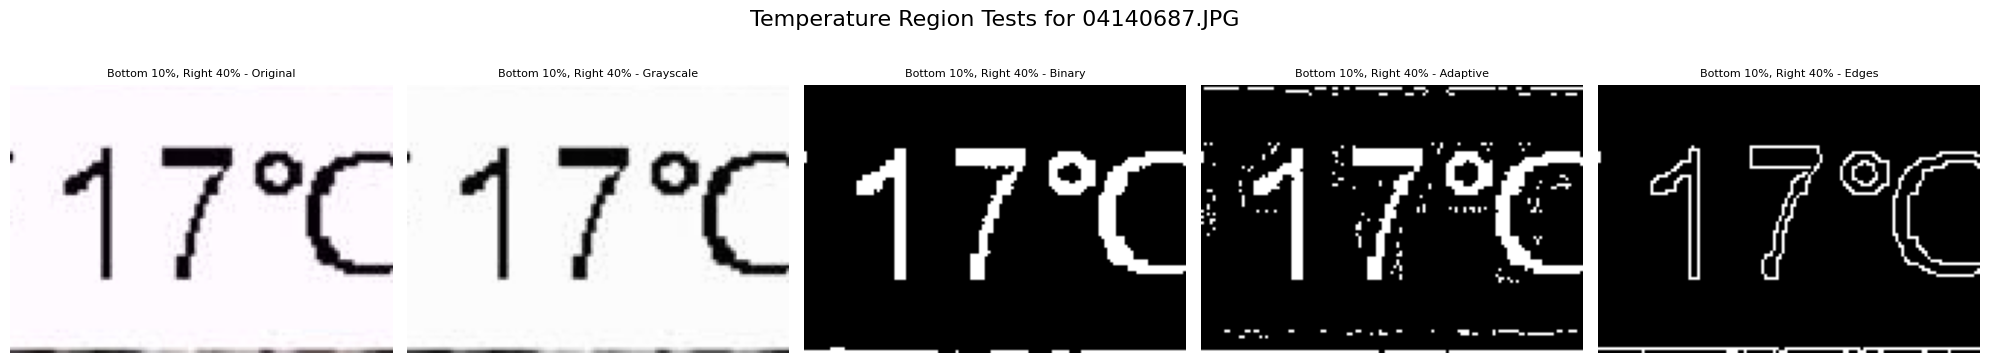

Processing image 10/20: ../data/camera_trap_dataset_filtered/animal_images/03170135.JPG


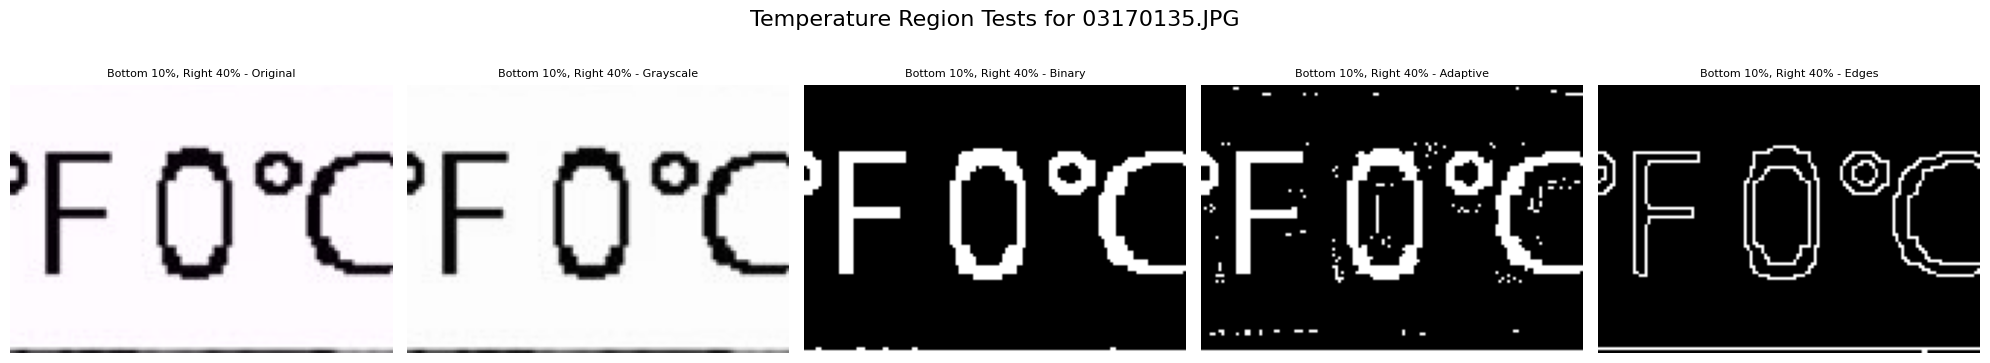

Processing image 11/20: ../data/camera_trap_dataset_filtered/animal_images/04210052.JPG


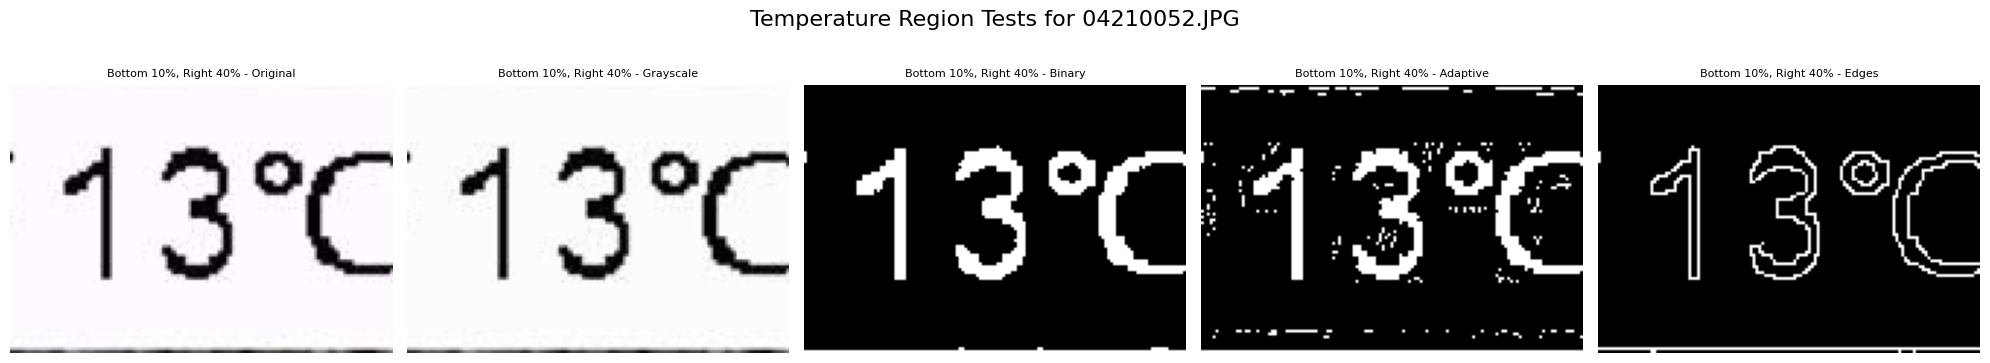

Processing image 12/20: ../data/camera_trap_dataset_filtered/animal_images/03180180.JPG


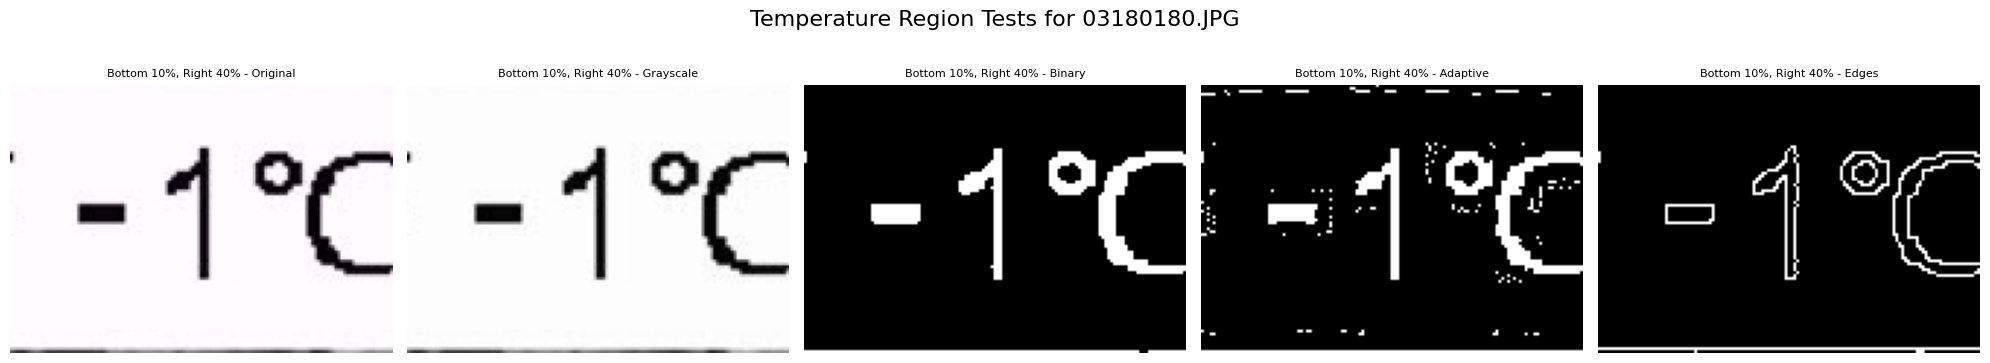

Processing image 13/20: ../data/camera_trap_dataset_filtered/animal_images/03060740.JPG


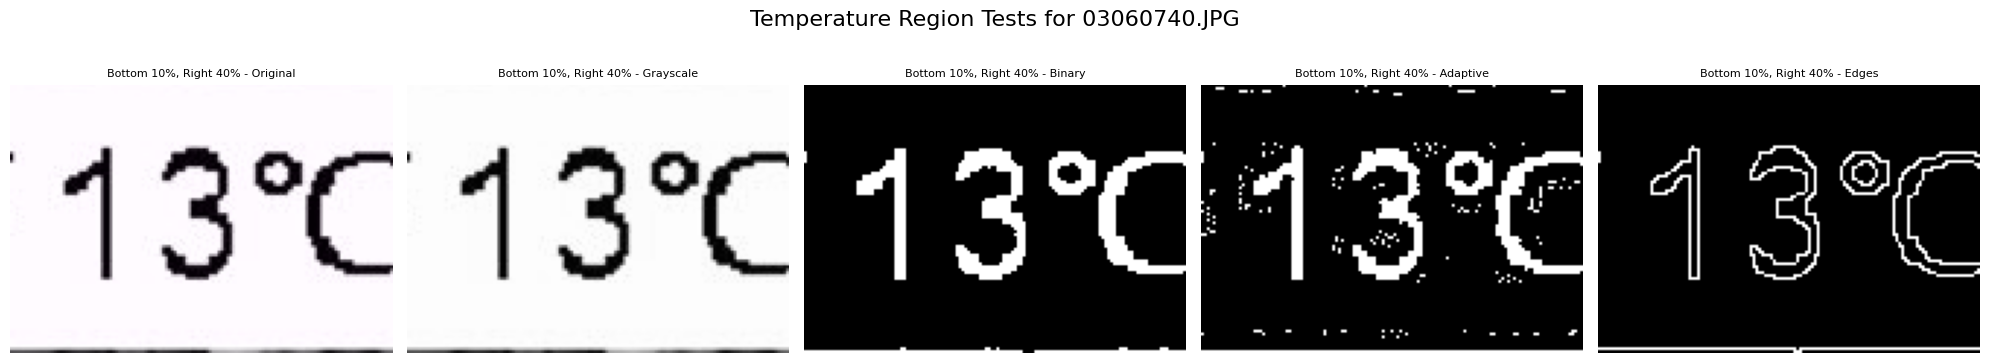

Processing image 14/20: ../data/camera_trap_dataset_filtered/animal_images/02270503.JPG


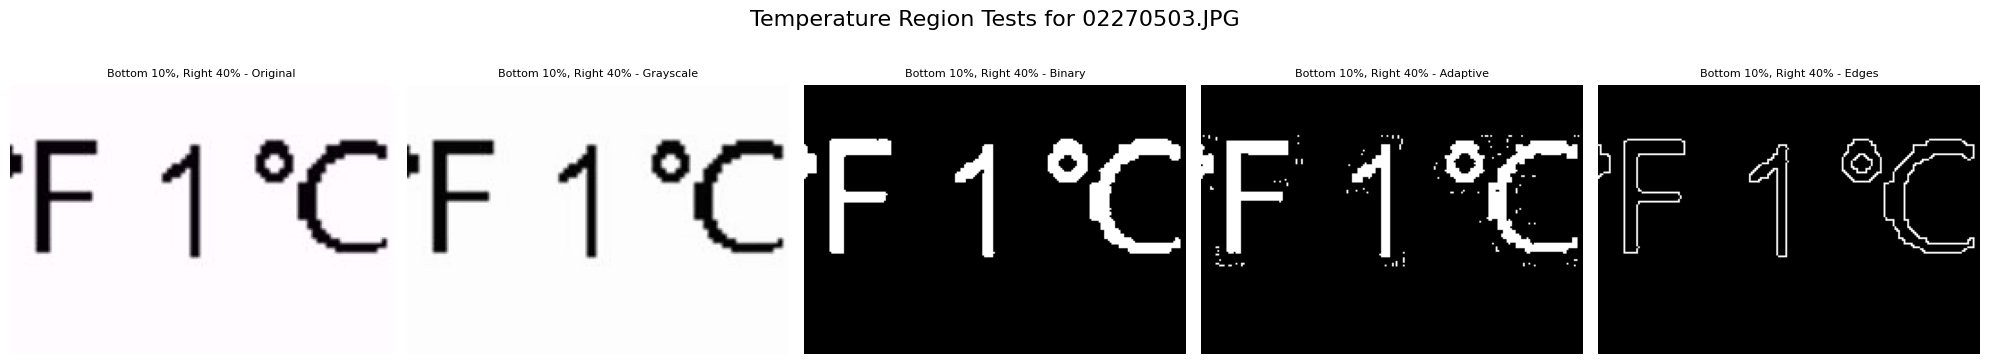

Processing image 15/20: ../data/camera_trap_dataset_filtered/animal_images/04060175.JPG


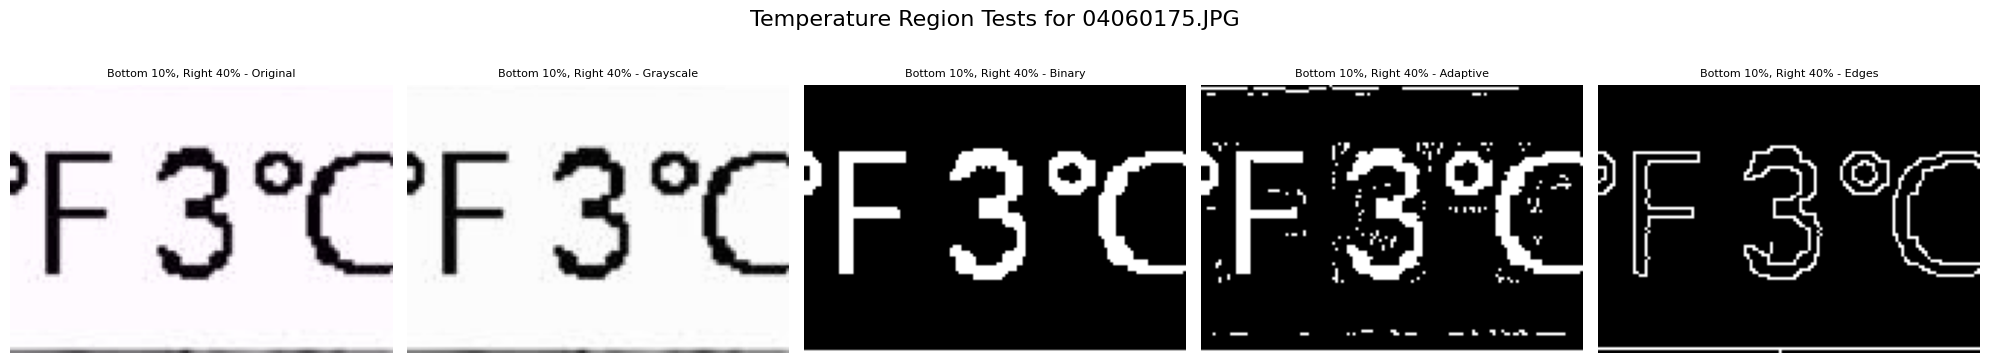

Processing image 16/20: ../data/camera_trap_dataset_filtered/animal_images/02110002.JPG


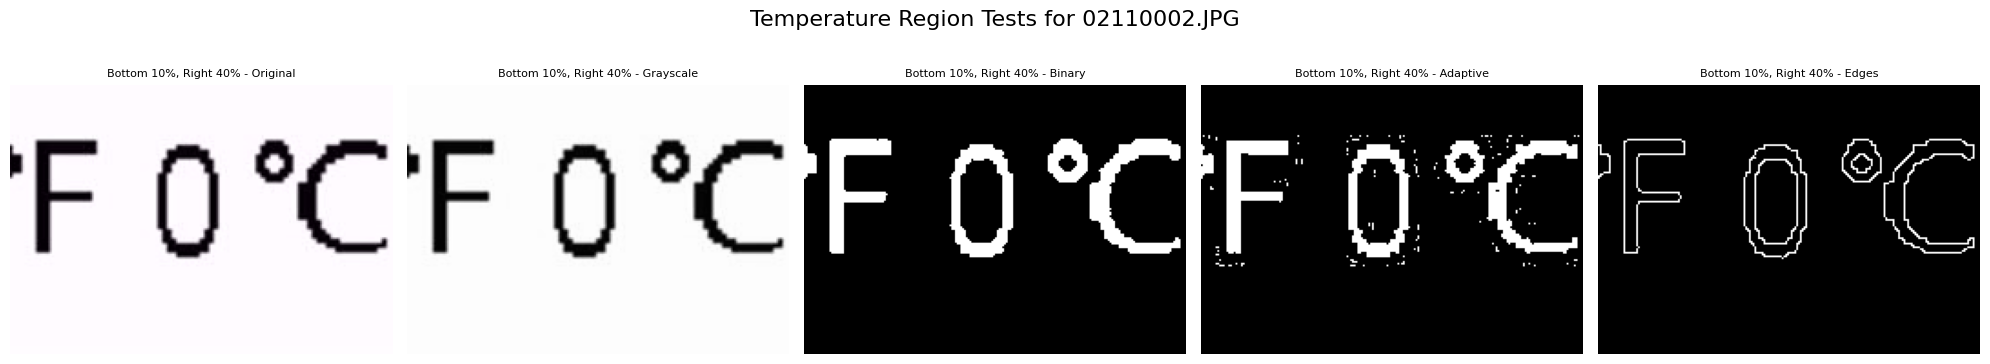

Processing image 17/20: ../data/camera_trap_dataset_filtered/animal_images/05070448.JPG


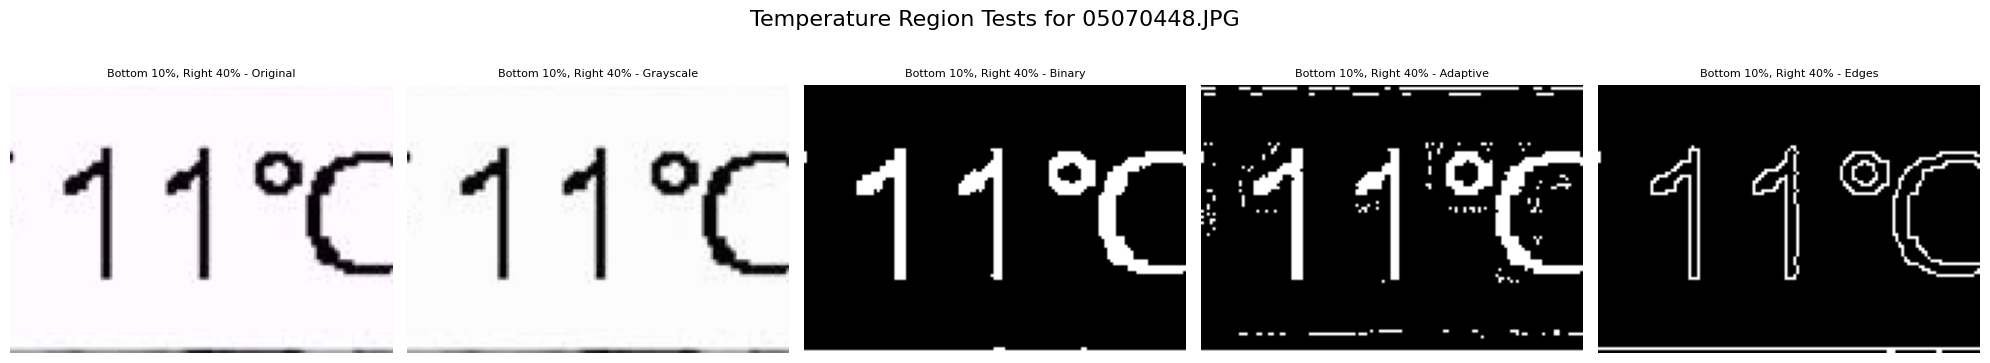

Processing image 18/20: ../data/camera_trap_dataset_filtered/animal_images/03170085.JPG


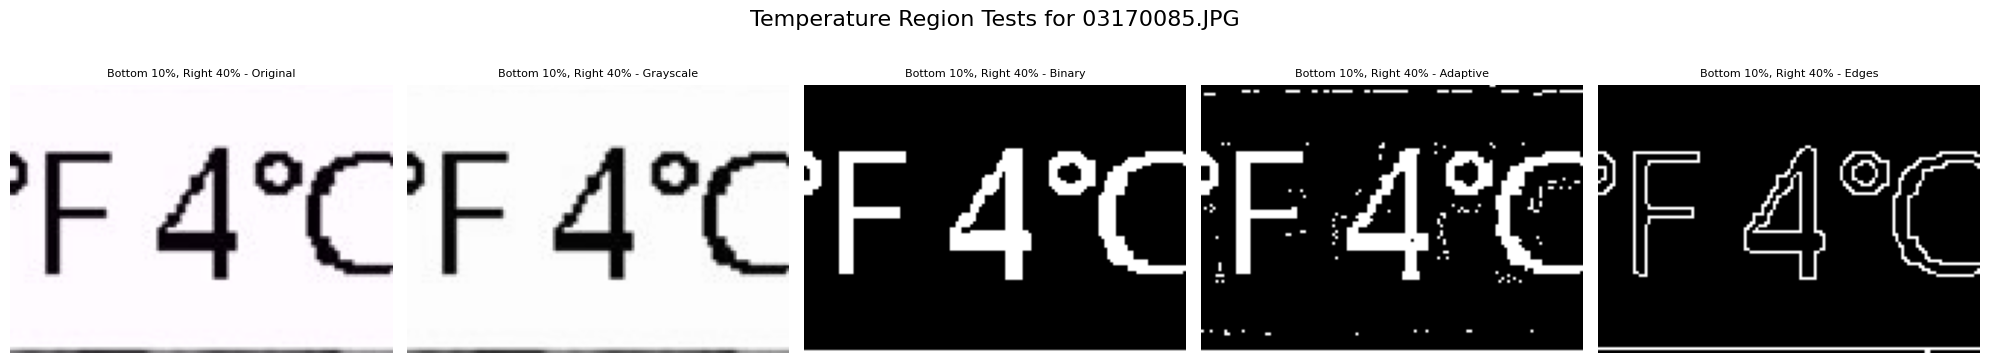

Processing image 19/20: ../data/camera_trap_dataset_filtered/animal_images/02050575.JPG


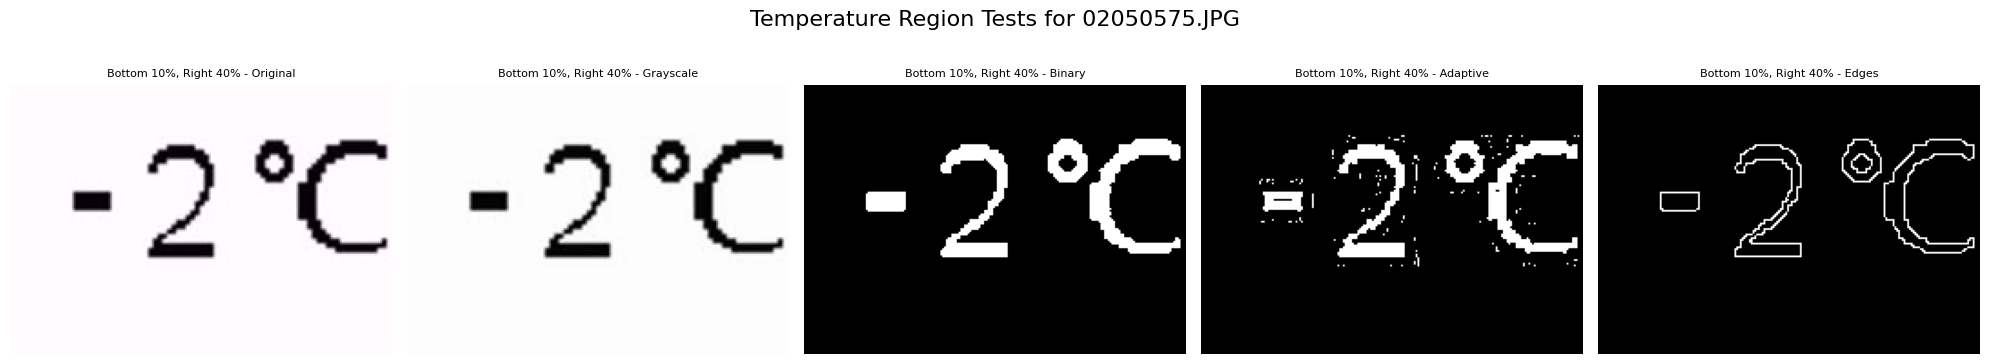

Processing image 20/20: ../data/camera_trap_dataset_filtered/animal_images/02270489.JPG


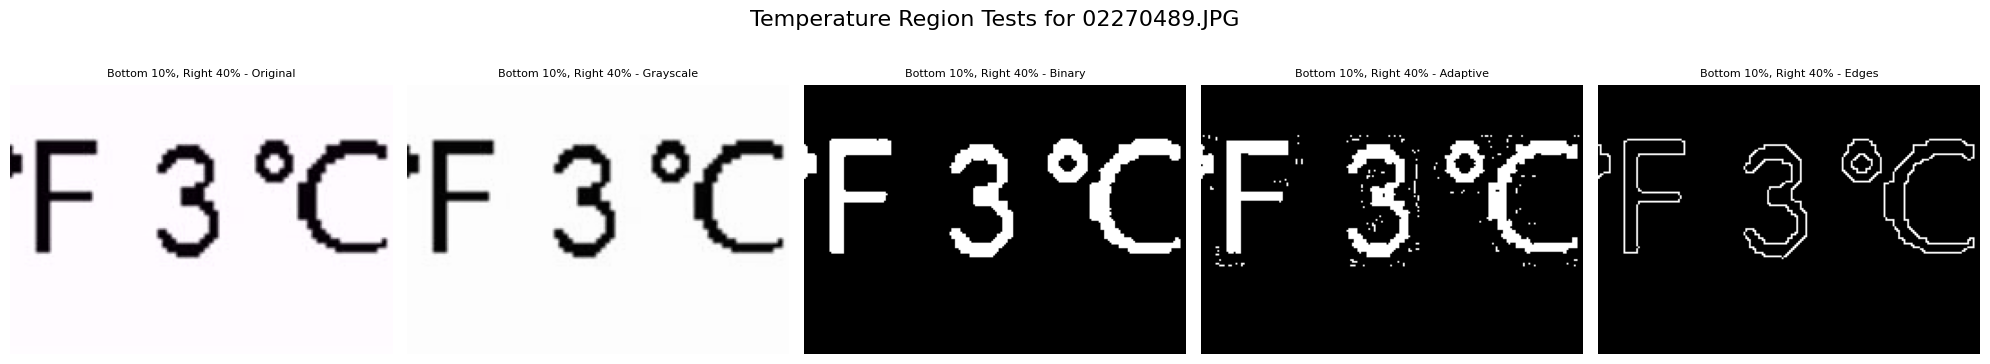

In [20]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import glob
import os

def test_temperature_region_crops(img_path, save_results=False):
    """Test different cropping approaches for temperature readings"""
    # Read the image
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Could not read {img_path}")
        return None
        
    # Get image dimensions
    h, w = img.shape[:2]
    file_name = os.path.basename(img_path)
    
    # Create different crop regions to test
    crops = {
        "Bottom 10%, Right 40%": img[int(h*0.95):, int(w*0.43):int(w*0.47)],
        #"Bottom 10%, Right 30%": img[int(h*0.90):, int(w*0.70):],
        #"Bottom 8%, Right 35%": img[int(h*0.92):, int(w*0.65):],
        #"Bottom 15%, Right 45%": img[int(h*0.85):, int(w*0.55):],
        #"Bottom Right Corner": img[int(h*0.90):, int(w*0.80):],
    }
    
    # Test preprocessing approaches
    preprocessed = {}
    for name, crop in crops.items():
        if crop.size == 0:
            continue
            
        # Convert to grayscale
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        
        # Apply binary threshold
        _, binary = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
        
        # Apply adaptive threshold
        adaptive = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, 11, 2
        )
        
        # Apply edge detection
        edges = cv2.Canny(gray, 50, 150)
        
        preprocessed[f"{name} - Original"] = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        preprocessed[f"{name} - Grayscale"] = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        preprocessed[f"{name} - Binary"] = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
        preprocessed[f"{name} - Adaptive"] = cv2.cvtColor(adaptive, cv2.COLOR_GRAY2RGB)
        preprocessed[f"{name} - Edges"] = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    
    # Create a grid of images for visualization
    rows = len(preprocessed) // 5 + (1 if len(preprocessed) % 5 > 0 else 0)
    fig, axes = plt.subplots(rows, 5, figsize=(20, 4 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if len(preprocessed) <= 1 else axes
    
    for i, (name, img_crop) in enumerate(preprocessed.items()):
        if i < len(axes):
            axes[i].imshow(img_crop)
            axes[i].set_title(name, fontsize=8)
            axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(len(preprocessed), len(axes)):
        if rows > 1 or (rows == 1 and len(axes) > 1):
            axes[i].axis('off')
    
    plt.suptitle(f"Temperature Region Tests for {file_name}", fontsize=16)
    plt.tight_layout()
    
    if save_results:
        output_dir = "crop_test_results"
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(f"{output_dir}/{file_name}_crops.png")
    
    plt.show()
    return preprocessed

def test_multiple_images(directory="images/*.JPG", num_samples=3):
    """Test cropping on multiple sample images"""
    image_paths = glob.glob(directory, recursive=True)
    
    if not image_paths:
        print(f"No images found in {directory}")
        return
        
    print(f"Found {len(image_paths)} images, testing on {min(num_samples, len(image_paths))} samples")
    
    for i, img_path in enumerate(image_paths[:num_samples]):
        print(f"Processing image {i+1}/{min(num_samples, len(image_paths))}: {img_path}")
        test_temperature_region_crops(img_path, save_results=True)

# Example usage
if __name__ == "__main__":
    # For testing a single image
    # test_temperature_region_crops("../data/camera_trap_dataset_filtered/animal_images/02110016.JPG")
    
    # For testing multiple images
    test_multiple_images("../data/camera_trap_dataset_filtered/animal_images/*.JPG", num_samples=20)


In [21]:
import cv2
import pytesseract
import re
from pathlib import Path

def extract_temperature(img_path):
    # Read image
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Could not read {img_path}")
        return None
        
    # Extract bottom 10%, right 40% (where temperature appears to be)
    h, w = img.shape[:2]
    roi = img[int(h*0.95):, int(w*0.43):int(w*0.47)]
    
    # Convert to grayscale
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    
    # Apply binary threshold (works best based on your image)
    _, binary = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    
    # Configure Tesseract to only look for digits and minus sign
    custom_config = r'--psm 7 -c tessedit_char_whitelist=-0123456789'
    
    # Apply OCR with optimized configuration
    try:
        text = pytesseract.image_to_string(binary, config=custom_config).strip()
        
        # Use regex to extract just the number with optional minus sign
        match = re.search(r'(-?\d+)', text)
        if match:
            return int(match.group(1))
        else:
            return None
    except Exception as e:
        print(f"OCR error on {img_path}: {e}")
        return None

# Example usage
if __name__ == "__main__":
    # Test on a single image
    #temp = extract_temperature("path/to/your/image.JPG")
    #print(f"Extracted temperature: {temp}°C")
    
    # Or batch process
    import glob
    results = {}
    for img_path in glob.glob("../data/camera_trap_dataset_filtered/animal_images/*.JPG"):
        temp = extract_temperature(img_path)
        results[img_path] = temp
        if temp is not None:
            print(f"{img_path}: {temp}°C")
    
    # Optional: Save results to JSON
    import json
    with open("temperatures.json", "w") as f:
        json.dump(results, f, indent=2)


../data/camera_trap_dataset_filtered/animal_images/02030541.JPG: 1°C
../data/camera_trap_dataset_filtered/animal_images/02100895.JPG: 1°C
../data/camera_trap_dataset_filtered/animal_images/04200954.JPG: 10°C
../data/camera_trap_dataset_filtered/animal_images/04200971.JPG: 10°C
../data/camera_trap_dataset_filtered/animal_images/04240234.JPG: 13°C
../data/camera_trap_dataset_filtered/animal_images/02270488.JPG: 3°C
../data/camera_trap_dataset_filtered/animal_images/03090773.JPG: 12°C
../data/camera_trap_dataset_filtered/animal_images/02120109.JPG: 1°C
../data/camera_trap_dataset_filtered/animal_images/04140687.JPG: 1°C
../data/camera_trap_dataset_filtered/animal_images/03170135.JPG: 0°C
../data/camera_trap_dataset_filtered/animal_images/04210052.JPG: 13°C
../data/camera_trap_dataset_filtered/animal_images/03060740.JPG: 13°C
../data/camera_trap_dataset_filtered/animal_images/02270503.JPG: 1°C
../data/camera_trap_dataset_filtered/animal_images/04060175.JPG: 3°C
../data/camera_trap_dataset_

In [1]:
!tesseract --version

tesseract 5.4.1
 leptonica-1.82.0
  libgif 5.2.1 : libjpeg 8d (libjpeg-turbo 2.1.5) : libpng 1.6.43 : libtiff 4.5.1 : zlib 1.3 : libwebp 1.3.2 : libopenjp2 2.5.0
 Found AVX512BW
 Found AVX512F
 Found AVX512VNNI
 Found AVX2
 Found AVX
 Found FMA
 Found SSE4.1
 Found OpenMP 201511
 Found libarchive 3.7.2 zlib/1.3 liblzma/5.4.5 bz2lib/1.0.8 liblz4/1.9.4 libzstd/1.5.5
 Found libcurl/8.5.0 OpenSSL/3.0.13 zlib/1.3 brotli/1.1.0 zstd/1.5.5 libidn2/2.3.7 libpsl/0.21.2 (+libidn2/2.3.7) libssh/0.10.6/openssl/zlib nghttp2/1.59.0 librtmp/2.3 OpenLDAP/2.6.7
